In [1]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller

## Data collection 

In [2]:
tickers="AAPL, MSFT, AMZN, NVDA, GOOGL, GOOG, META, TSLA, BRK-B, UNH, JNJ, JPM, V, PG, XOM, HD, MA, CVX, MRK, ABBV, AVGO, COST, KO, PEP, WMT, BAC, CRM, DIS, ORCL, TMO, ACN, NFLX, LIN, ABT, MCD, CSCO, DHR, VZ, WFC, INTU, CMCSA, ADP, TXN, IBM, PM, NKE, RTX, HON, QCOM, UPS, LOW, BMY, AMGN, SPGI, SCHW, CAT, GS, BLK, MDLZ, CVS, AXP, DE, MS, AMT, C, BA, T, ISRG, NOW, GILD, LMT, ADI, MMM, MO, SYK, ZTS, CB, TJX, ETN, CI, SO, VRTX, PGR, MU, PLD, REGN, USB, WM, BK, KLAC, LRCX, FIS, ICE, APD, HCA, SHW, EL, NOC"
tickers_list = tickers.split(", ")

In [3]:
df = yf.download(
    tickers,
    start="2018-01-01",
    interval="1d",
    auto_adjust=True,
    group_by="tickers",
    threads=True
)

[*********************100%***********************]  98 of 98 completed


In [4]:
df.shape

(2094, 490)

In [5]:
df.head()

Ticker            INTU                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2018-01-02  148.932031  149.525053  147.793055  149.402679  1436100   
2018-01-03  148.941374  149.976806  148.480148  149.816788  1410900   
2018-01-04  150.099276  154.203333  150.099276  152.499573  1695000   
2018-01-05  153.243191  154.890461  152.960799  154.476288  1071900   
2018-01-08  154.400963  154.871612  153.751466  154.570404  1185800   

Ticker            COST                                               ...  \
Price             Open        High         Low       Close   Volume  ...   
Date                                                                 ...   
2018-01-02  167.280160  170.362551  166.842380  168.254028  2509300  ...   
2018-01-03  168.700701  171.631206  168.307582  170.273163  3364400  ...   
2018-01-04  171.541889  171.809926  167.574981  168.950897  3525800  ...   
2018-01-05  169.245767  169.469129  166.824532  167.744781  2819000  ...   
2018-01-08  167.360569  168.843681  167.298021  168.396957  1961800  ...   

Ticker             NOC                                                  GOOGL  \
Price             Open        High         Low       Close  Volume       Open   
Date                                                                            
2018-01-02  268.902033  269.225743  265.279913  267.055969  715000  52.219407   
2018-01-03  266.618601  268.814621  266.504859  268.289673  722100  53.256336   
2018-01-04  268.228341  270.091892  267.379682  269.951904  582400  54.404847   
2018-01-05  270.424371  271.430506  268.779545  269.663208  842800  54.720241   
2018-01-08  270.301929  270.643128  269.094556  269.698242  660800  55.094642   

Ticker                                                 
Price            High        Low      Close    Volume  
Date                                                   
2018-01-02  53.357996  52.219407  53.220631  31766000  
2018-01-03  54.355751  53.231543  54.128628  31318000  
2018-01-04  54.751480  54.264508  54.338890  26052000  
2018-01-05  55.222590  54.638417  55.059437  30250000  
2018-01-08  55.499299  55.045053  55.253826  24644000  

[5 rows x 490 columns]

## Data Cleaning 

In [6]:
df = df.xs("Close", axis=1, level=1).pct_change().dropna()
df=pd.DataFrame(df)
df.head()

Ticker,INTU,COST,BAC,QCOM,ACN,V,ZTS,CMCSA,ABT,APD,...,AXP,GS,CVS,C,LOW,LIN,ICE,BRK-B,NOC,GOOGL
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.002772,0.012001,-0.003345,0.011350,0.004615,0.009955,0.004598,-0.016070,0.002211,0.005438,...,0.006165,-0.009309,-0.004352,0.003093,0.004366,0.008387,0.015176,0.013031,0.004620,0.017061
2018-01-04,0.017907,-0.007766,0.013087,0.001365,0.011841,0.003718,0.005964,0.006434,-0.001697,0.003846,...,0.016633,0.013976,0.026366,0.012334,0.007825,0.015683,0.018897,0.004505,0.006196,0.003884
2018-01-05,0.012962,-0.007139,0.004637,0.006664,0.008249,0.023949,0.011444,0.009098,0.002890,0.008381,...,0.002281,-0.005100,0.044190,-0.001324,0.021566,0.008751,0.008304,0.003637,-0.001069,0.013260
2018-01-08,0.000609,0.003888,-0.006924,-0.003009,0.007991,0.004038,0.011995,-0.013645,-0.002882,0.001069,...,-0.009201,-0.014519,-0.008668,-0.011670,-0.010872,-0.000372,0.003707,0.006554,0.000130,0.003531
2018-01-09,0.006287,-0.011619,0.004980,-0.015090,0.003335,-0.001927,0.011719,0.003212,0.001700,0.002550,...,0.003694,0.008459,-0.001029,0.010466,0.008963,0.009733,0.012718,0.001381,0.006910,-0.001274


#### Row Return to Log Return

In [7]:
import numpy as np
returns = np.log(1+df)
returns.head()

Ticker,INTU,COST,BAC,QCOM,ACN,V,ZTS,CMCSA,ABT,APD,...,AXP,GS,CVS,C,LOW,LIN,ICE,BRK-B,NOC,GOOGL
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.002768,0.011929,-0.003350,0.011286,0.004604,0.009906,0.004588,-0.016200,0.002209,0.005423,...,0.006146,-0.009353,-0.004362,0.003088,0.004356,0.008352,0.015062,0.012947,0.004609,0.016917
2018-01-04,0.017749,-0.007796,0.013002,0.001364,0.011771,0.003711,0.005946,0.006413,-0.001699,0.003839,...,0.016496,0.013879,0.026025,0.012259,0.007794,0.015561,0.018721,0.004495,0.006177,0.003877
2018-01-05,0.012879,-0.007164,0.004627,0.006642,0.008215,0.023667,0.011379,0.009056,0.002886,0.008346,...,0.002278,-0.005113,0.043241,-0.001325,0.021337,0.008713,0.008270,0.003631,-0.001070,0.013173
2018-01-08,0.000609,0.003880,-0.006948,-0.003014,0.007960,0.004030,0.011924,-0.013739,-0.002886,0.001068,...,-0.009243,-0.014626,-0.008706,-0.011738,-0.010931,-0.000372,0.003700,0.006532,0.000130,0.003524
2018-01-09,0.006267,-0.011687,0.004968,-0.015205,0.003329,-0.001929,0.011651,0.003206,0.001699,0.002547,...,0.003688,0.008423,-0.001029,0.010411,0.008923,0.009686,0.012638,0.001380,0.006886,-0.001275


#### Average Correlation between  the selected assets

In [8]:
returns.corr().mean().mean()

np.float64(0.3849840652101934)

## Checking the stationarity

In [9]:
results = returns.apply(lambda col: adfuller(col)[1])  # Extract p-values for each asset's returns
results = pd.Series(results, index=returns.columns)
results.max()

np.float64(2.6818017048868756e-14)

## PCA application

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [11]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

In [12]:
pca = PCA()
pca.fit(returns_scaled)

PCA()

In [13]:
eigenvalues      = pd.Series(pca.explained_variance_)          # variance of each PC
eigenvectors     = pd.DataFrame(pca.components_)                  # shape: (N_components, N_assets)
explained_ratio  = pd.Series(pca.explained_variance_ratio_)    # % variance per PC
cumulative_var   = np.cumsum(explained_ratio)

In [14]:
eigenvalues.head()

0    38.709703
1     6.334332
2     4.700881
3     2.199785
4     1.844059
dtype: float64

In [15]:
eigenvectors.head()

,0,1,2,3,4,5,6,7,8,9,...,88,89,90,91,92,93,94,95,96,97
0,0.108686,0.093860,0.122721,0.098912,0.117415,0.126516,0.106625,0.096756,0.101631,0.105619,...,0.123498,0.122676,0.076444,0.121141,0.110381,0.118589,0.108238,0.130327,0.070663,0.103845
1,0.127976,0.018509,-0.017378,0.154084,0.045876,0.022480,-0.001071,-0.040600,-0.053899,-0.047061,...,0.013050,0.033093,-0.107129,0.006984,0.006755,-0.024073,-0.017288,-0.070366,-0.139006,0.157888
2,-0.103656,-0.145446,0.217834,-0.013850,-0.055893,-0.009927,-0.134660,0.003073,-0.144937,-0.015695,...,0.168301,0.185338,0.016408,0.218094,-0.030649,-0.007770,-0.059487,0.080139,-0.014019,-0.067392
3,-0.159845,-0.025129,0.010325,0.104742,-0.128059,-0.130287,-0.032681,0.013873,0.022746,0.008331,...,-0.074451,0.027035,0.129535,0.003593,-0.036900,-0.029550,-0.165632,-0.015912,-0.015500,-0.015883
4,-0.111270,0.158576,-0.095501,0.147807,-0.104202,-0.103422,-0.062624,0.013125,-0.113952,0.056995,...,-0.067293,-0.047297,-0.065658,-0.076178,0.147355,0.033611,-0.059034,-0.045867,0.023666,-0.046573


In [16]:
explained_ratio

0     0.394808
1     0.064605
2     0.047945
3     0.022436
4     0.018808
        ...   
93    0.001176
94    0.000982
95    0.000927
96    0.000850
97    0.000040
Length: 98, dtype: float64

In [17]:
cumulative_var.tail()

93    0.997200
94    0.998183
95    0.999110
96    0.999960
97    1.000000
dtype: float64

## The Marchenko-Pastur filter 

In [18]:
T, N = returns_scaled.shape
lambda_noise = (1 + np.sqrt(N / T))**2
signal_eigenvalues  = eigenvalues[eigenvalues.values > lambda_noise].reset_index(drop=True)
signal_eigenvectors = eigenvectors[eigenvalues.values > lambda_noise]  # shape: (n_signal, N_assets)
n_signal = np.sum(eigenvalues.values > lambda_noise)
print(f"T={T}, N={N}")
print(f"Noise threshold (lambda_max): {lambda_noise:.4f}")
print(f"Signal PCs: {n_signal}")

T=2093, N=98
Noise threshold (lambda_max): 1.4796
Signal PCs: 7


## Equal weighted Portfolio 

#### Construction

In [19]:
N = returns.shape[1]
weights = np.ones(N) / N
weights

array([0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020408,
       0.01020408, 0.01020408, 0.01020408, 0.01020408, 0.01020

In [20]:
portfolio_returns = returns @ weights
portfolio_returns.columns = ['Returns']
portfolio_returns.describe()

count    2093.000000
mean        0.000494
std         0.011865
min        -0.131752
25%        -0.004241
50%         0.000725
75%         0.006090
max         0.097721
dtype: float64

<Axes: title={'center': 'Equal-Weighted Portfolio Returns'}, xlabel='Date'>

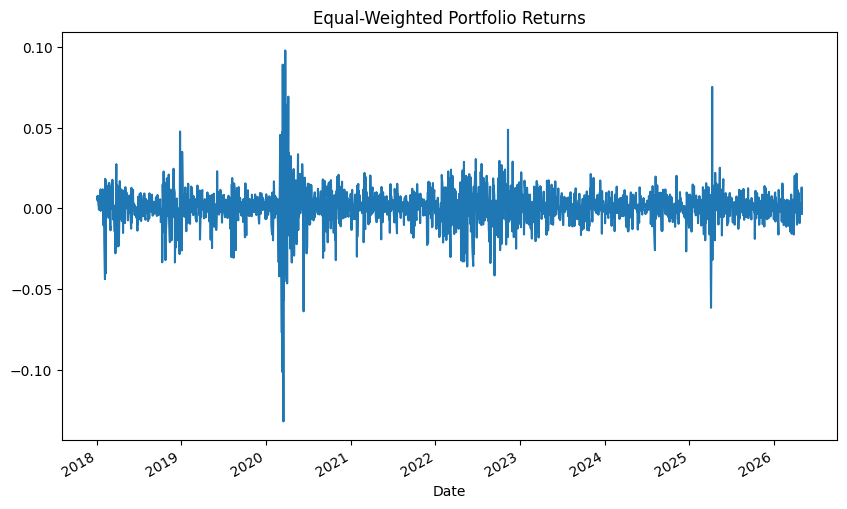

In [21]:
portfolio_returns.plot(title='Equal-Weighted Portfolio Returns', figsize=(10,6))

<Axes: title={'center': 'Cumulative Returns of Equal-Weighted Portfolio'}, xlabel='Date'>

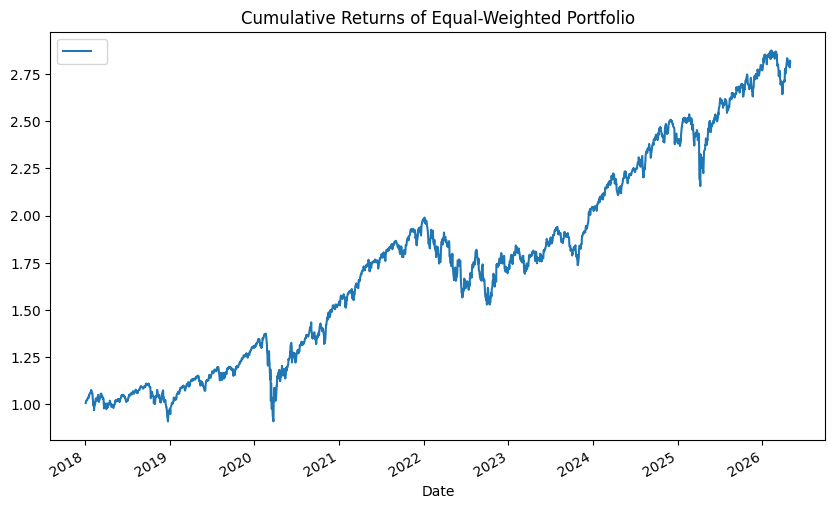

In [22]:
cum_returns = np.exp(portfolio_returns.cumsum()) # cumulative product of (1 + returns) to get wealth index
cum_returns.plot(title='Cumulative Returns of Equal-Weighted Portfolio', figsize=(10,6),legend=True)

#### Maximum Drawdown / Sharp ratio

In [23]:
wealth_index=cum_returns
previous_peak = wealth_index.cummax()

<Axes: title={'center': 'Wealth Index and Drawdown'}, xlabel='Date'>

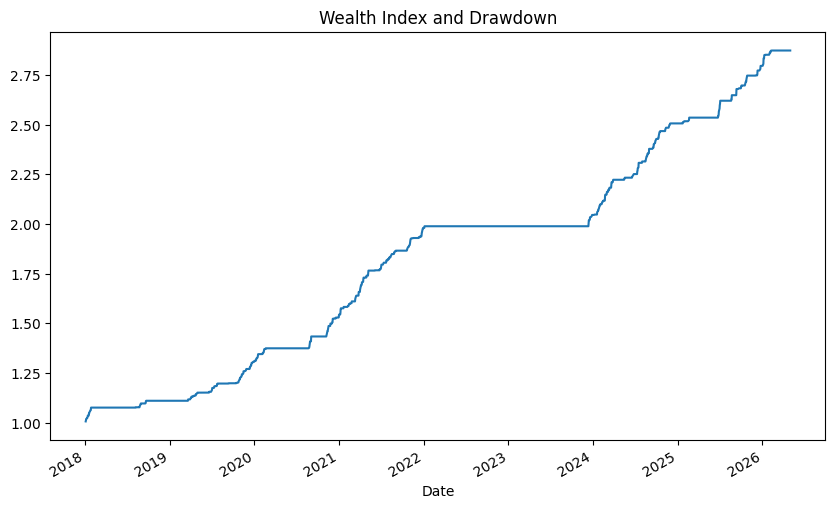

In [24]:
previous_peak.plot(title='Wealth Index and Drawdown', figsize=(10,6), label='Wealth Index')

In [25]:
ew_drawdown = (wealth_index - previous_peak) / previous_peak
print('Max drawdown of', ew_drawdown.min().round(2))

Max drawdown of -0.34


<Axes: title={'center': 'Drawdown'}, xlabel='Date'>

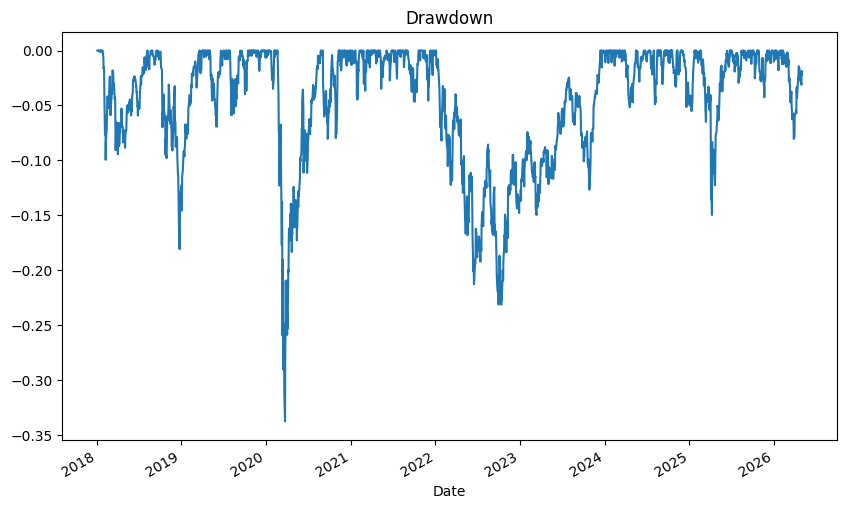

In [26]:
ew_drawdown.plot(title="Drawdown", figsize=(10,6))

In [27]:
ew_ann_return = portfolio_returns.mean() * 252
ew_ann_vol = portfolio_returns.std() * np.sqrt(252)
ew_sharpe = ew_ann_return / ew_ann_vol

print("Equal-weighted portfolio")
print(f"Annualized return      : {ew_ann_return:.4f}")
print(f"Annualized volatility  : {ew_ann_vol:.4f}")
print(f"Sharpe ratio           : {ew_sharpe:.4f}")

Equal-weighted portfolio
Annualized return      : 0.1244
Annualized volatility  : 0.1883
Sharpe ratio           : 0.6606


#### E-Q Portfolio risk exposure 

In [28]:
pc_exposure = signal_eigenvectors @ weights
variance_contrib = (pc_exposure**2) * signal_eigenvalues
variance_contrib = variance_contrib / variance_contrib.sum()
variance_contrib*100

0    99.872149
1     0.026965
2     0.063500
3     0.018259
4     0.000030
5     0.018763
6     0.000334
dtype: float64

In [29]:
p   = variance_contrib
ENB = np.exp(-np.sum(p * np.log(p + 1e-10))) # add small constant to avoid log(0)

In [30]:
print(f"Assets in portfolio      : {N}")
print(f"Signal PCs (real factors): {n_signal}")
print(f"Effective Number of Bets : {ENB:.2f}")
print(f"Diversification Ratio    : {ENB / N * 100:.2f}%")
print(f"")
print(f"Interpretation: your {N}-asset portfolio")
print(f"behaves like {ENB:.1f} independent bets")
print(f"out of a possible {N}")

Assets in portfolio      : 98
Signal PCs (real factors): 7
Effective Number of Bets : 1.01
Diversification Ratio    : 1.03%

Interpretation: your 98-asset portfolio
behaves like 1.0 independent bets
out of a possible 98


## interpretation of the 7 real factors

In [31]:
tickers = list(returns.columns)

loadings = pd.DataFrame(
    signal_eigenvectors.values,
    index   = [f'PC{i}' for i in range(n_signal)],
    columns = tickers
)
loadings

,INTU,COST,BAC,QCOM,ACN,V,ZTS,CMCSA,ABT,APD,...,AXP,GS,CVS,C,LOW,LIN,ICE,BRK-B,NOC,GOOGL
PC0,0.108686,0.093860,0.122721,0.098912,0.117415,0.126516,0.106625,0.096756,0.101631,0.105619,...,0.123498,0.122676,0.076444,0.121141,0.110381,0.118589,0.108238,0.130327,0.070663,0.103845
PC1,0.127976,0.018509,-0.017378,0.154084,0.045876,0.022480,-0.001071,-0.040600,-0.053899,-0.047061,...,0.013050,0.033093,-0.107129,0.006984,0.006755,-0.024073,-0.017288,-0.070366,-0.139006,0.157888
PC2,-0.103656,-0.145446,0.217834,-0.013850,-0.055893,-0.009927,-0.134660,0.003073,-0.144937,-0.015695,...,0.168301,0.185338,0.016408,0.218094,-0.030649,-0.007770,-0.059487,0.080139,-0.014019,-0.067392
PC3,-0.159845,-0.025129,0.010325,0.104742,-0.128059,-0.130287,-0.032681,0.013873,0.022746,0.008331,...,-0.074451,0.027035,0.129535,0.003593,-0.036900,-0.029550,-0.165632,-0.015912,-0.015500,-0.015883
PC4,-0.111270,0.158576,-0.095501,0.147807,-0.104202,-0.103422,-0.062624,0.013125,-0.113952,0.056995,...,-0.067293,-0.047297,-0.065658,-0.076178,0.147355,0.033611,-0.059034,-0.045867,0.023666,-0.046573
PC5,0.035537,0.120336,-0.049086,0.005620,-0.036421,0.026912,-0.162115,0.054987,-0.110116,-0.071535,...,-0.038134,-0.047503,0.136979,-0.041425,-0.186844,-0.038604,-0.036002,0.053508,0.249546,0.145862
PC6,0.006990,-0.107252,-0.142872,0.001620,0.009621,0.050950,0.091859,-0.215339,0.045133,0.013634,...,-0.003676,-0.098105,-0.030501,-0.083448,0.021989,0.041079,0.052609,-0.051221,0.275420,-0.099442


In [32]:
pc_labels = {
    'PC0': 'Market Beta',
    'PC1': 'Secular Growth vs Defensive Income',
    'PC2': 'Banking vs Quality Defensives',
    'PC3': 'Biotech vs Financial Software',
    'PC4': 'Semiconductor Equipment vs Pharma',
    'PC5': 'Defense & Media vs Precision Instruments',
    'PC6': 'Pure Defense vs Telecom'
}

for pc in loadings.index:
    row     = loadings.loc[pc]
    top_pos = row.nlargest(3)
    top_neg = row.nsmallest(3)
    label   = pc_labels[pc]

    print(f"\n{'='*55}")
    print(f"{pc} — {label}")
    print(f"{'='*55}")
    print(f"  Top positive loaders:")
    for ticker, val in top_pos.items():
        print(f"    {ticker:<10} {val:+.4f}")
    print(f"  Top negative loaders:")
    for ticker, val in top_neg.items():
        print(f"    {ticker:<10} {val:+.4f}")


PC0 — Market Beta
  Top positive loaders:
    BLK        +0.1312
    BRK-B      +0.1303
    MS         +0.1267
  Top negative loaders:
    REGN       +0.0643
    NFLX       +0.0672
    VZ         +0.0687

PC1 — Secular Growth vs Defensive Income
  Top positive loaders:
    NVDA       +0.2184
    AMZN       +0.1951
    LRCX       +0.1772
  Top negative loaders:
    SO         -0.1836
    KO         -0.1780
    VZ         -0.1734

PC2 — Banking vs Quality Defensives
  Top positive loaders:
    C          +0.2181
    WFC        +0.2181
    BAC        +0.2178
  Top negative loaders:
    PG         -0.1587
    TMO        -0.1465
    PEP        -0.1460

PC3 — Biotech vs Financial Software
  Top positive loaders:
    REGN       +0.2719
    GILD       +0.2545
    AMGN       +0.2519
  Top negative loaders:
    ICE        -0.1656
    SPGI       -0.1608
    INTU       -0.1598

PC4 — Semiconductor Equipment vs Pharma
  Top positive loaders:
    LRCX       +0.1844
    WMT        +0.1677
    PEP   

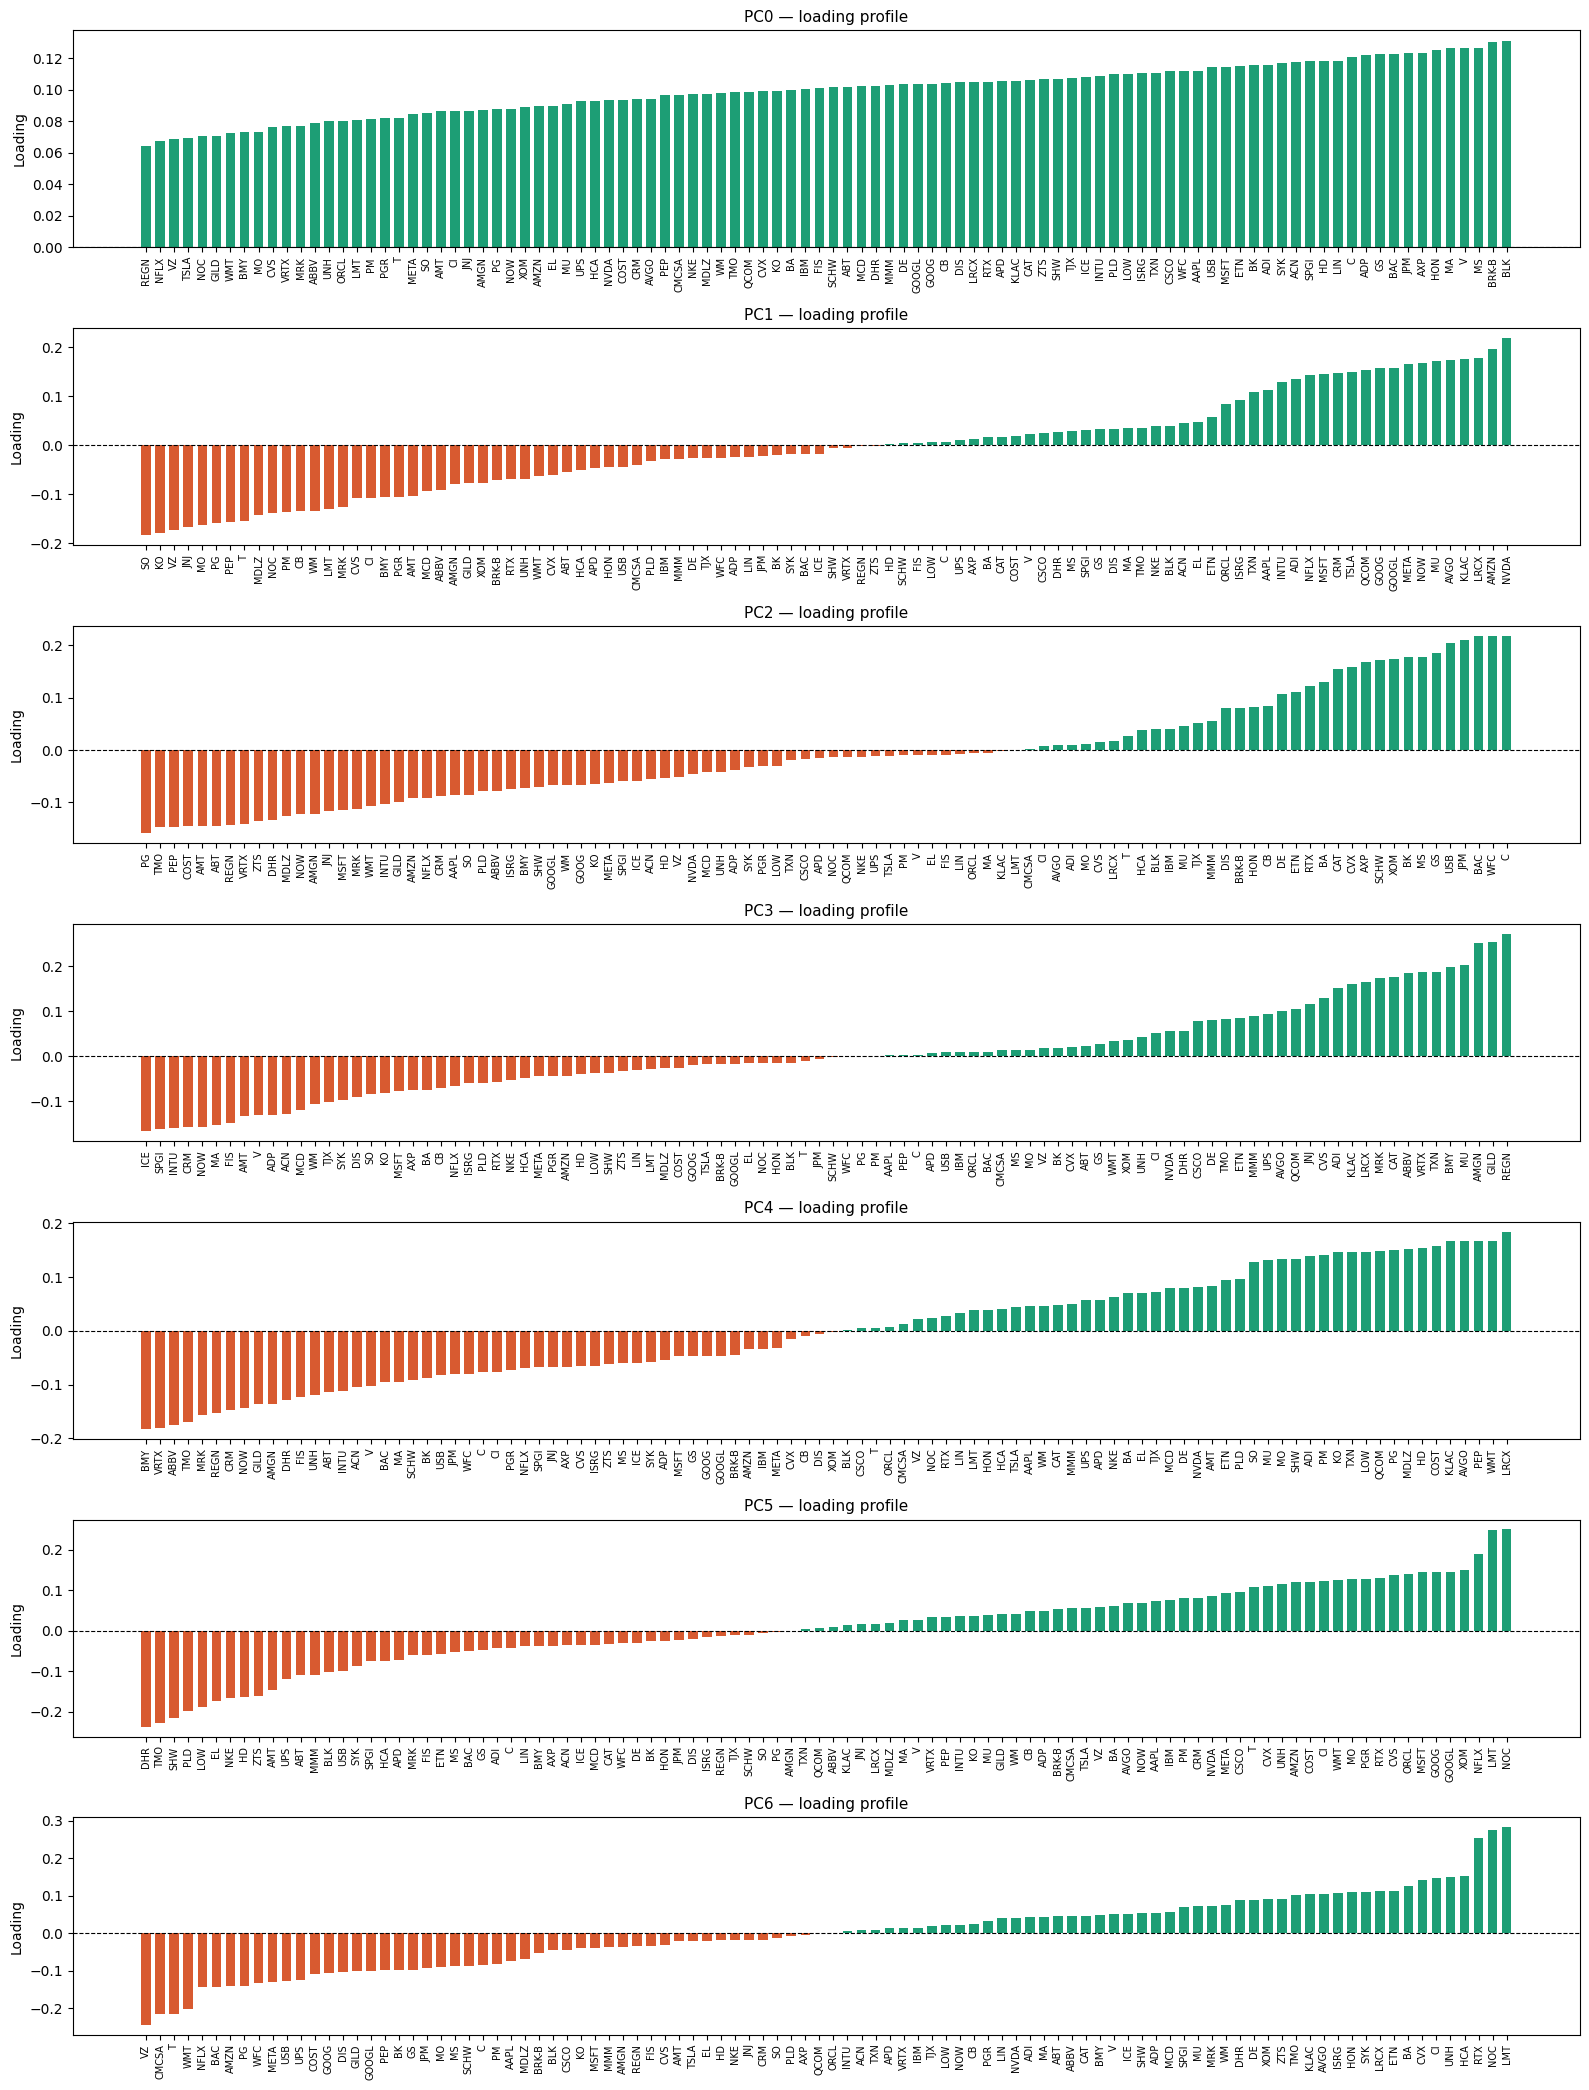

In [33]:
from matplotlib import pyplot as plt


fig, axes = plt.subplots(n_signal, 1, figsize=(16, 3 * n_signal))

for i, pc in enumerate(loadings.index):
    row    = loadings.loc[pc].sort_values()
    colors = ['#D85A30' if v < 0 else '#1D9E75' for v in row.values]
    
    axes[i].bar(row.index, row.values, color=colors, width=0.7)
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_title(f'{pc} — loading profile', fontsize=11)
    axes[i].set_xticks(range(len(row)))
    axes[i].set_xticklabels(row.index, rotation=90, fontsize=7)
    axes[i].set_ylabel('Loading')

plt.tight_layout()
plt.show()

#### PCs Growth 

In [34]:
# Rolling window parameters
window  = 252        # 1 trading year
step    = 21         # roll forward 1 month at a time

dates        = []
pc0_shares   = []
n_signals    = []
enbs         = []

for start in range(0, T - window, step):
    end     = start + window
    window_returns = returns_scaled[start:end, :]

    # PCA on this window
    pca_roll = PCA()
    pca_roll.fit(window_returns)

    ev_roll  = pca_roll.explained_variance_
    evec_roll = pca_roll.components_

    # Marchenko-Pastur for this window
    T_w, N_w      = window_returns.shape
    lam_noise     = (1 + np.sqrt(N_w / T_w))**2
    sig_mask      = ev_roll > lam_noise
    n_sig         = sig_mask.sum()

    sig_ev        = ev_roll[sig_mask]
    sig_evec      = evec_roll[sig_mask]

    # PC0 share of total explained variance
    pc0_share     = sig_ev[0] / sig_ev.sum()

    # ENB of equal-weighted portfolio in this window
    betas_roll    = sig_evec @ weights
    rc_roll       = (betas_roll**2) * sig_ev
    p_roll        = rc_roll / rc_roll.sum()
    enb_roll      = np.exp(-np.sum(p_roll * np.log(p_roll + 1e-10)))

    # Record date at end of window
    dates.append(returns.index[end - 1])
    pc0_shares.append(pc0_share)
    n_signals.append(n_sig)
    enbs.append(enb_roll)

# Build results DataFrame
roll_df = pd.DataFrame({
    'PC0_share' : pc0_shares,
    'N_signal'  : n_signals,
    'ENB'       : enbs
}, index=dates)

print(roll_df.describe().round(4))

       PC0_share  N_signal      ENB
count    88.0000   88.0000  88.0000
mean      0.6864    4.0227   1.0944
std       0.1093    1.3977   0.0902
min       0.4164    2.0000   1.0022
25%       0.5926    3.0000   1.0350
50%       0.6878    4.0000   1.0633
75%       0.7888    5.0000   1.1354
max       0.8741    7.0000   1.4368


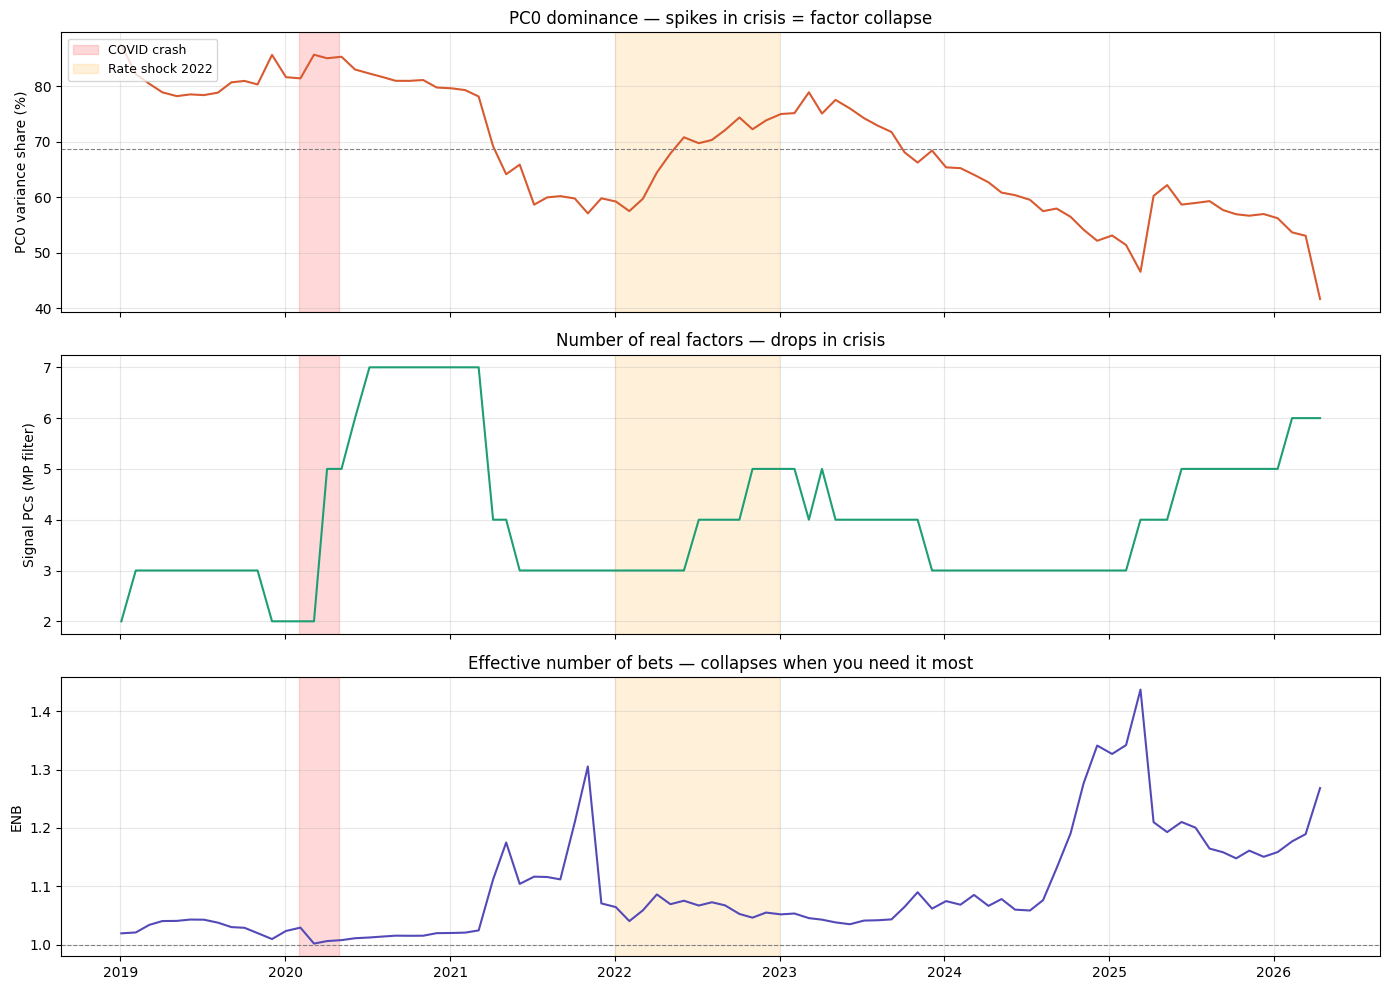

In [35]:
# Plot all three rolling metrics
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 — PC0 dominance over time
axes[0].plot(roll_df.index, roll_df['PC0_share'] * 100,
             color='#D85A30', linewidth=1.5)
axes[0].axhline(roll_df['PC0_share'].mean() * 100,
                linestyle='--', color='gray', linewidth=0.8)
axes[0].set_ylabel('PC0 variance share (%)')
axes[0].set_title('PC0 dominance — spikes in crisis = factor collapse')
axes[0].grid(True, alpha=0.3)

# Mark crisis periods
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-02-01'),
               pd.Timestamp('2020-04-30'),
               alpha=0.15, color='red', label='COVID crash')
    ax.axvspan(pd.Timestamp('2022-01-01'),
               pd.Timestamp('2022-12-31'),
               alpha=0.15, color='orange', label='Rate shock 2022')

# Panel 2 — number of signal PCs over time
axes[1].plot(roll_df.index, roll_df['N_signal'],
             color='#1D9E75', linewidth=1.5)
axes[1].set_ylabel('Signal PCs (MP filter)')
axes[1].set_title('Number of real factors — drops in crisis')
axes[1].grid(True, alpha=0.3)

# Panel 3 — rolling ENB
axes[2].plot(roll_df.index, roll_df['ENB'],
             color='#534AB7', linewidth=1.5)
axes[2].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[2].set_ylabel('ENB')
axes[2].set_title('Effective number of bets — collapses when you need it most')
axes[2].grid(True, alpha=0.3)

axes[0].legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Benckmark

In [36]:
ticker=yf.Ticker("^GSPC")
sp500 = ticker.history(start="2018-01-01")

In [37]:
sp500 = sp500['Close'].pct_change().dropna()
sp500 = sp500.rename('returns')

In [38]:
sp500_r=(1+sp500).cumprod() 
sp500_r=pd.DataFrame(sp500_r)
sp500_r.index=pd.to_datetime(sp500_r.index, format="%D/%m/%Y").to_period('D')

C:\Users\PC\AppData\Local\Temp\ipykernel_174608\373091507.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sp500_r.index=pd.to_datetime(sp500_r.index, format="%D/%m/%Y").to_period('D')


In [39]:
excess_returns = sp500_r['returns'].iloc[-1] - cum_returns.iloc[-1]
excess_returns

np.float64(-0.12870174357489406)

## PC Risk Parity Portfolio

In [41]:
from scipy.optimize import minimize

# signal eigenvectors and eigenvalues from your full-sample PCA
V = signal_eigenvectors.values   # shape: (7, 97)
L = signal_eigenvalues.values    # shape: (7,)

def risk_contributions(w):
    betas = V @ w
    rc    = (betas**2) * L
    return rc / rc.sum()

def objective(w):
    rc     = risk_contributions(w)
    target = np.ones(n_signal) / n_signal
    return np.sum((rc - target)**2)

# cap each asset at 5% maximum weight
cap = 0.1

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds      = [(0.001, cap)] * N
w0          = np.ones(N) / N

result = minimize(
    objective, w0,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = constraints,
    options     = {'maxiter': 1000, 'ftol': 1e-12}
)

w_pcrp = result.x

print(f"Optimization success : {result.success}")
print(f"Max weight           : {w_pcrp.max():.4f}  ({tickers[w_pcrp.argmax()]})")
print(f"Non-zero weights     : {(w_pcrp > 0.001).sum()}")
# Compute ENB for PCRP
betas_pcrp = signal_eigenvectors.values @ w_pcrp
rc_pcrp = (betas_pcrp**2) * signal_eigenvalues.values
var_shares = rc_pcrp / rc_pcrp.sum()
p_pcrp = var_shares
enb_pcrp = np.exp(-np.sum(p_pcrp * np.log(p_pcrp + 1e-10)))

print(f"ENB                  : {enb_pcrp:.4f}")

Optimization success : True
Max weight           : 0.1000  (VZ)
Non-zero weights     : 76
ENB                  : 3.5031


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:438: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:492: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


In [42]:
pcrp_returns = returns.values @ w_pcrp
pcrp_returns = pd.Series(pcrp_returns, index=returns.index)
pcrp_returns.describe()

count    2093.000000
mean        0.000372
std         0.010752
min        -0.080793
25%        -0.004999
50%         0.000510
75%         0.006389
max         0.066746
dtype: float64

In [43]:
pcrp_cumulative = (1 + pcrp_returns).cumprod()
pcrp_cumulative

Date
2018-01-03    1.005882
2018-01-04    1.005755
2018-01-05    1.013110
2018-01-08    1.008256
2018-01-09    1.015321
                ...   
2026-04-27    1.922978
2026-04-28    1.928208
2026-04-29    1.914142
2026-04-30    1.952504
2026-05-01    1.931413
Length: 2093, dtype: float64

In [44]:
pcrp_ann_return = pcrp_returns.mean() * 252
pcrp_ann_vol    = pcrp_returns.std()  * np.sqrt(252)
pcrp_sharpe = pcrp_ann_return / pcrp_ann_vol

print(f"Annualized Return : {pcrp_ann_return:.4f}")
print(f"Annualized Vol    : {pcrp_ann_vol:.4f}")
print(f"Sharpe Ratio : {pcrp_sharpe:.4f}")

Annualized Return : 0.0939
Annualized Vol    : 0.1707
Sharpe Ratio : 0.5499


In [45]:
pcrp_peak     = pcrp_cumulative.cummax()
pcrp_drawdown = (pcrp_cumulative - pcrp_peak) / pcrp_peak
pcrp_mdd      = pcrp_drawdown.min()

print(f"Max Drawdown : {pcrp_mdd:.2f}")

Max Drawdown : -0.20


## Risk Contribution pcrp

In [46]:
betas_pcrp  = signal_eigenvectors.values @ w_pcrp
rc_pcrp     = (betas_pcrp**2) * signal_eigenvalues.values
var_shares  = rc_pcrp / rc_pcrp.sum()
p_pcrp      = var_shares
enb_pcrp    = np.exp(-np.sum(p_pcrp * np.log(p_pcrp + 1e-10)))

risk_df = pd.DataFrame({
    'Variance_Share' : var_shares,
    'Risk_Contrib'   : rc_pcrp
}, index=[f'PC{i} — {pc_labels[f"PC{i}"]}' for i in range(n_signal)])

print(risk_df.round(4))
print(f"\nENB PCRP             : {enb_pcrp:.4f}")
betas_ew     = signal_eigenvectors.values @ weights
rc_ew        = (betas_ew**2) * signal_eigenvalues.values
var_shares_ew = rc_ew / rc_ew.sum()
enb_ew       = np.exp(-np.sum(var_shares_ew * np.log(var_shares_ew + 1e-10)))

print(f"ENB Equal-Weighted   : {enb_ew:.4f}")
print(f"Diversification Ratio: {enb_pcrp/N*100:.2f}%")

                                                Variance_Share  Risk_Contrib
PC0 — Market Beta                                       0.5816        0.2378
PC1 — Secular Growth vs Defensive Income                0.1072        0.0438
PC2 — Banking vs Quality Defensives                     0.0993        0.0406
PC3 — Biotech vs Financial Software                     0.1485        0.0607
PC4 — Semiconductor Equipment vs Pharma                 0.0608        0.0248
PC5 — Defense & Media vs Precision Instruments          0.0002        0.0001
PC6 — Pure Defense vs Telecom                           0.0024        0.0010

ENB PCRP             : 3.5031
ENB Equal-Weighted   : 1.0115
Diversification Ratio: 3.57%


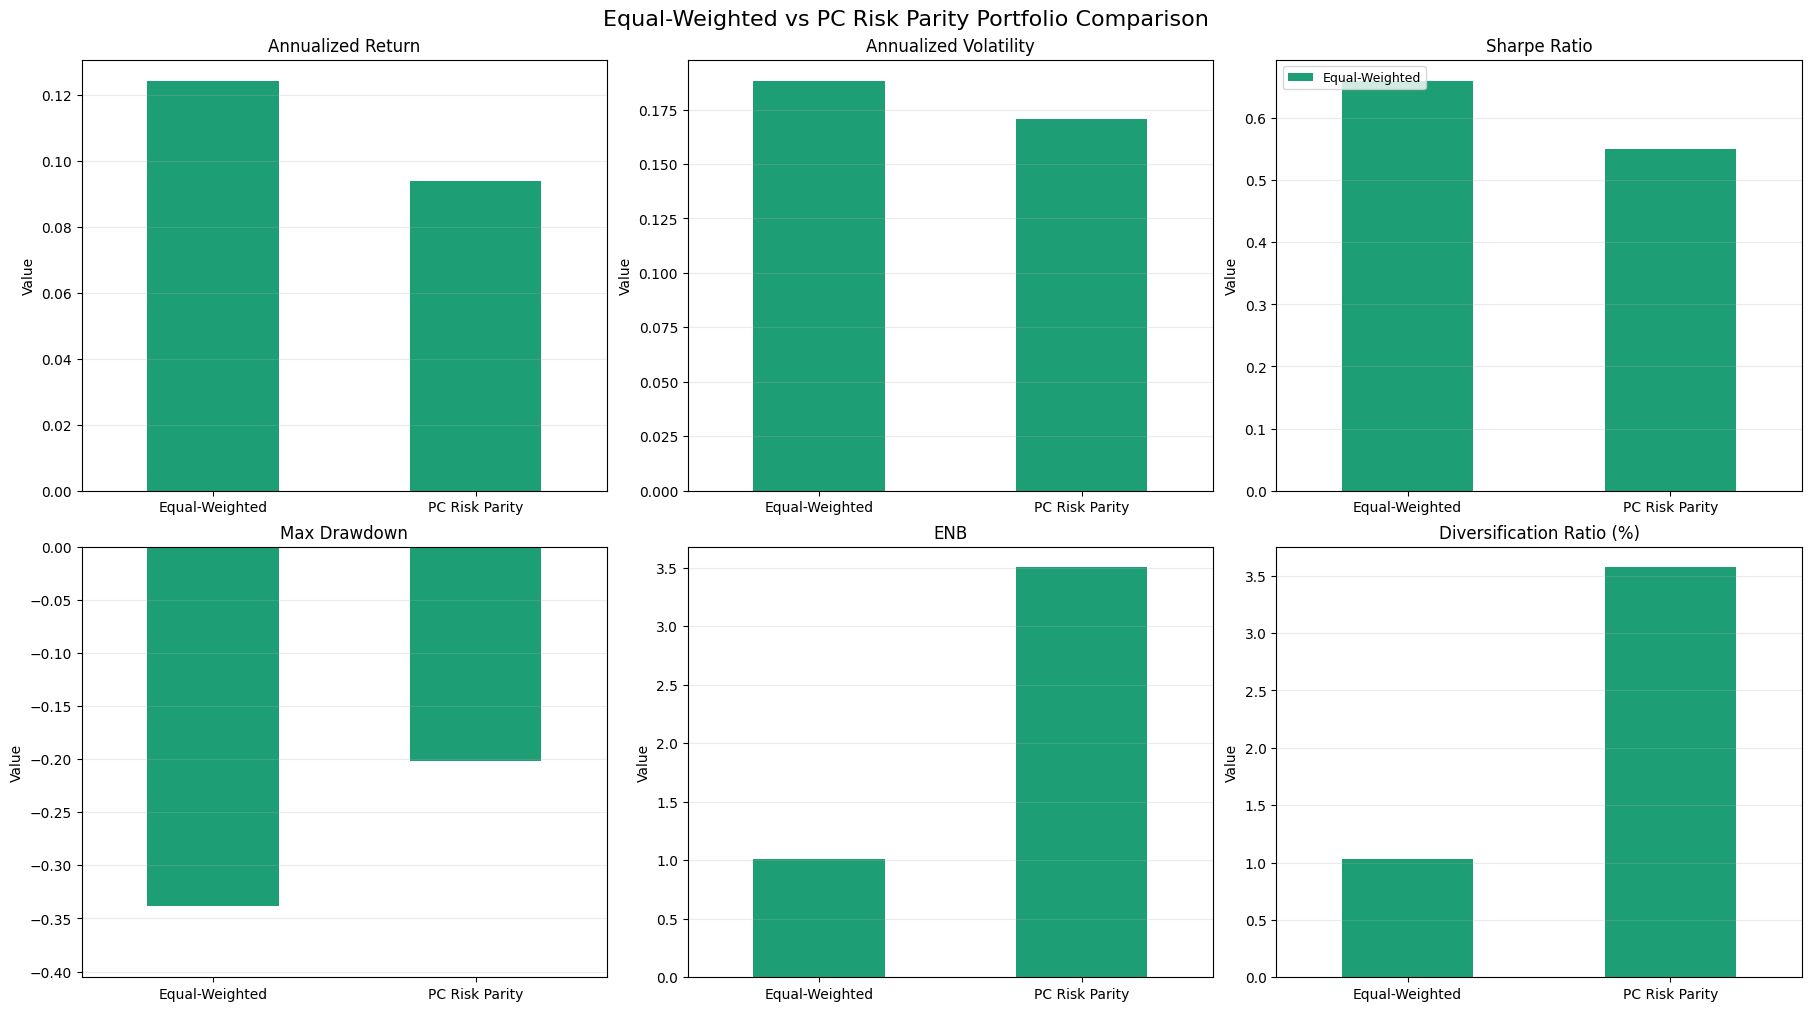

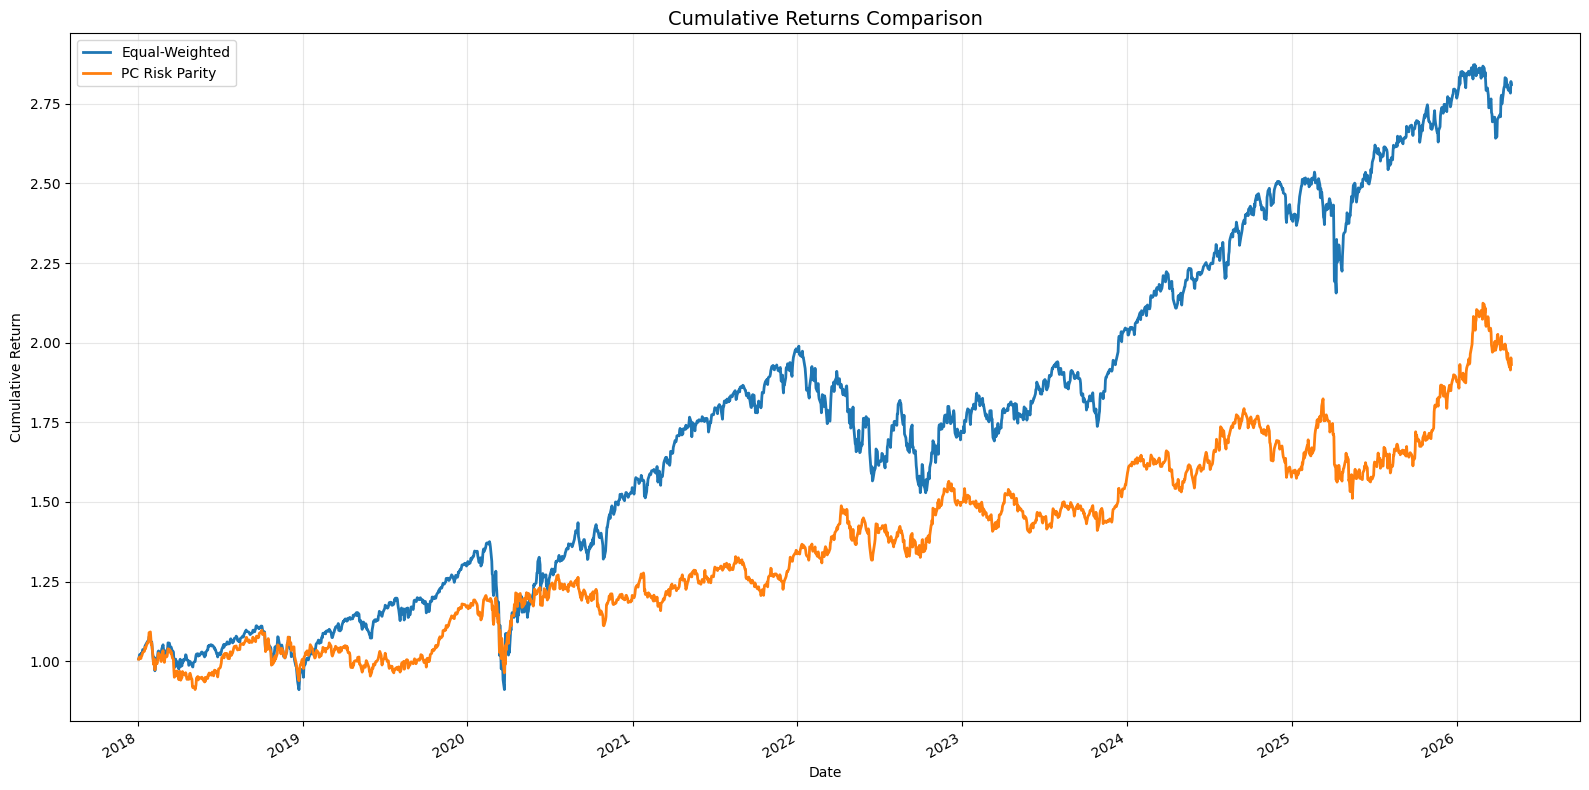

In [48]:
comparison = pd.DataFrame({
    'Equal-Weighted': [
        ew_ann_return,
        ew_ann_vol,
        ew_sharpe,
        ew_drawdown.min(),
        enb_ew,
        enb_ew / N * 100
    ],
    'PC Risk Parity': [
        pcrp_ann_return,
        pcrp_ann_vol,
        pcrp_sharpe,
        pcrp_mdd,
        enb_pcrp,
        enb_pcrp / N * 100
    ]
}, index=[
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Max Drawdown',
    'ENB',
    'Diversification Ratio (%)'
])

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for ax, metric in zip(axes.flatten(), comparison.index):
    comparison.loc[[metric]].T.plot(
        kind='bar',
        ax=ax,
        color=['#1D9E75', '#D85A30'],
        legend=False,
        rot=0
    )
    ax.set_title(metric)
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.25)
    if metric == 'Max Drawdown':
        ax.set_ylim(comparison.loc['Max Drawdown'].min() * 1.2, 0)

for ax in axes[-1, :]:
    ax.set_xlabel('')

axes[0, 2].legend(comparison.columns, loc='upper left', fontsize=9)

plt.suptitle('Equal-Weighted vs PC Risk Parity Portfolio Comparison', fontsize=16)
plt.show()

# Add cumulative returns comparison
cum_returns_comparison = pd.DataFrame({
    'Equal-Weighted': cum_returns,
    'PC Risk Parity': pcrp_cumulative
})

fig, ax = plt.subplots(figsize=(16, 8))
cum_returns_comparison.plot(ax=ax, linewidth=2)
ax.set_title('Cumulative Returns Comparison', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PCRP sacrifices 3.8% annual return and 0.15 Sharpe points to achieve a 3.8x improvement in factor diversification and a 13 percentage point reduction in maximum drawdown — a trade-off that is rational for any investor whose primary constraint is drawdown tolerance rather than return maximization.

In [49]:
# save final weights
np.save('w_pcrp_final.npy', w_pcrp)
np.save('w_ew_final.npy',   weights)
print("Weights saved.")

Weights saved.


## Crisis stress test 

In [54]:
# define crisis periods
crises = {
    'COVID Crash'    : ('2020-02-01', '2020-04-30'),
    'Rate Shock 2022': ('2022-01-01', '2022-12-31')
}

results = []

for crisis_name, (start, end) in crises.items():
    
    # subset returns
    ew_crisis   = portfolio_returns[start:end]
    pcrp_crisis = pcrp_returns[start:end]
    
    # cumulative
    ew_cum   = (1 + ew_crisis).cumprod()
    pcrp_cum = (1 + pcrp_crisis).cumprod()
    
    # sharpe
    ew_sharpe_c   = (ew_crisis.mean() / ew_crisis.std()) * np.sqrt(252)
    pcrp_sharpe_c = (pcrp_crisis.mean() / pcrp_crisis.std()) * np.sqrt(252)
    
    # MDD
    ew_mdd_c   = ((ew_cum - ew_cum.cummax()) / ew_cum.cummax()).min()
    pcrp_mdd_c = ((pcrp_cum - pcrp_cum.cummax()) / pcrp_cum.cummax()).min()
    
    # total return over period
    ew_total   = ew_cum.iloc[-1] - 1
    pcrp_total = pcrp_cum.iloc[-1] - 1
    
    # ENB during crisis window — fixed indexing
    idx_start  = returns.index.get_indexer(
                     [pd.Timestamp(start)], method='nearest')[0]
    idx_end    = returns.index.get_indexer(
                     [pd.Timestamp(end)],   method='nearest')[0]
    
    ret_window = returns_scaled[idx_start:idx_end]
    
    pca_c  = PCA()
    pca_c.fit(ret_window)
    ev_c   = pca_c.explained_variance_
    evc_c  = pca_c.components_
    lam_c  = (1 + np.sqrt(ret_window.shape[1] / ret_window.shape[0]))**2
    sig_c  = ev_c > lam_c
    ev_sig = ev_c[sig_c]
    evc_sig= evc_c[sig_c]
    
    # ENB of EW during crisis
    b_ew     = evc_sig @ weights
    rc_ew    = (b_ew**2) * ev_sig
    p_ew     = rc_ew / rc_ew.sum()
    enb_ew_c = np.exp(-np.sum(p_ew * np.log(p_ew + 1e-10)))
    
    # ENB of PCRP during crisis
    b_pc     = evc_sig @ w_pcrp
    rc_pc    = (b_pc**2) * ev_sig
    p_pc     = rc_pc / rc_pc.sum()
    enb_pc_c = np.exp(-np.sum(p_pc * np.log(p_pc + 1e-10)))
    
    results.append({
        'Crisis'            : crisis_name,
        'EW Total Return'   : ew_total,
        'PCRP Total Return' : pcrp_total,
        'EW MDD'            : ew_mdd_c,
        'PCRP MDD'          : pcrp_mdd_c,
        'EW Sharpe'         : ew_sharpe_c,
        'PCRP Sharpe'       : pcrp_sharpe_c,
        'EW ENB'            : enb_ew_c,
        'PCRP ENB'          : enb_pc_c,
        'Signal PCs'        : sig_c.sum()
    })

crisis_df = pd.DataFrame(results).set_index('Crisis')
print(crisis_df.round(4).T)

Crisis             COVID Crash  Rate Shock 2022
EW Total Return        -0.1300          -0.1504
PCRP Total Return       0.0505           0.1206
EW MDD                 -0.3602          -0.2464
PCRP MDD               -0.2015          -0.1146
EW Sharpe              -0.5690          -0.6169
PCRP Sharpe             0.6552           0.7792
EW ENB                  1.0088           1.0523
PCRP ENB                1.6830           2.7638
Signal PCs             10.0000           5.0000


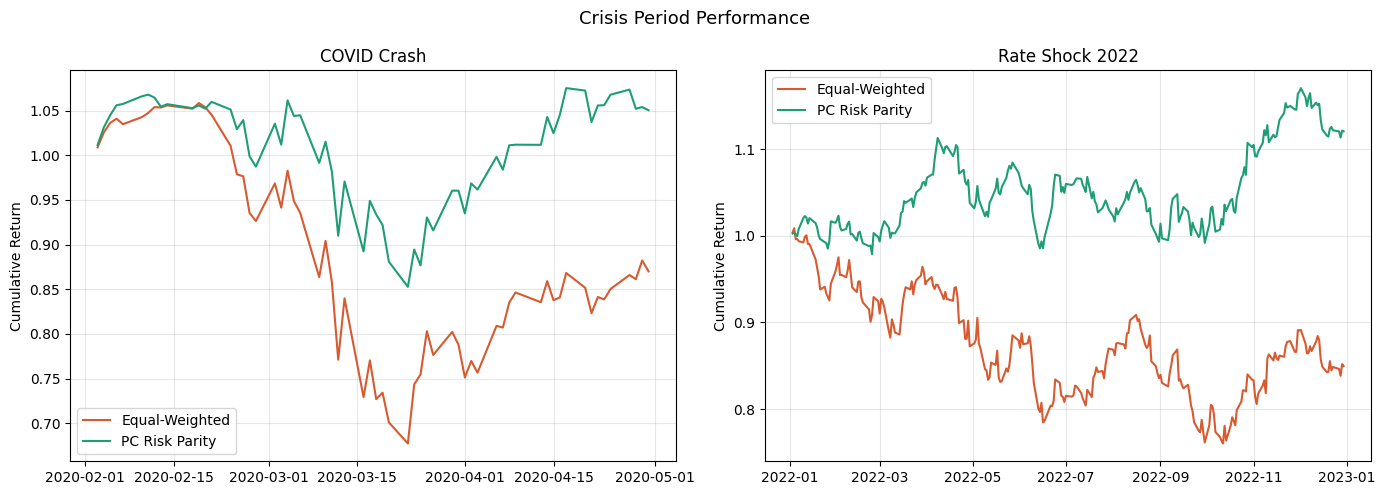

In [55]:
# plot crisis cumulative returns side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (crisis_name, (start, end)) in enumerate(crises.items()):
    ew_c   = (1 + portfolio_returns[start:end]).cumprod()
    pcrp_c = (1 + pcrp_returns[start:end]).cumprod()
    
    axes[i].plot(ew_c,   label='Equal-Weighted', color='#D85A30', linewidth=1.5)
    axes[i].plot(pcrp_c, label='PC Risk Parity', color='#1D9E75', linewidth=1.5)
    axes[i].set_title(crisis_name)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylabel('Cumulative Return')

plt.suptitle('Crisis Period Performance', fontsize=13)
plt.tight_layout()
plt.show()

- An equal-weighted portfolio of 97 US large-cap equities has an Effective Number of Bets of 1.01 — statistically equivalent to a single asset despite holding 97 positions. PC Risk Parity improves ENB to 3.5 under realistic constraints, but at a cost of 3% annual return and significantly lower cumulative wealth in bull markets.
The trade-off reveals itself most clearly in crisis periods. During the COVID crash and 2022 rate shock, PCRP generated positive returns of +5% and +12% respectively while EW lost -13% and -15%. Maximum drawdown was cut from -36% to -20% in COVID and from -25% to -11% in the rate shock.
However the full-period cumulative chart shows EW ending 40% ahead of PCRP — driven entirely by the 2020–2026 bull market and the AI-driven tech rally which PCRP's defensive positioning completely missed.
The conclusion is not that one portfolio is superior. It is that naive diversification across assets provides no factor diversification, and that factor diversification within a single equity asset class is structurally constrained by the long-only requirement. True diversification requires either short positions or genuine multi-asset-class exposure.